# Evaluacion final del rendimiento base sobre el conjunto de TEST

Plantilla para la evaluacion final de cada LLM sobre el conjunto de **prueba** (1,455 comentarios), usando el prompt ya seleccionado en la etapa de validacion (Tabla 15). Esta es la corrida que se reporta oficialmente como "rendimiento base" de cada modelo, y la unica vez que se toca el conjunto de test para este objetivo.

**Prompt seleccionado por modelo (a partir de validation):**

| Modelo | Prompt |
|---|---|
| Qwen3.5-9B | 4 |
| RigoChat-7b-v2 | 4 |
| Salamandra-7B-Instruct-2606 | 2 |
| EuroLLM-9B-Instruct | 3 |
| Gemma 4-12B-it | 1 |
| Llama 3.1-8B-Instruct | 1 |

## 1. Configuracion (unica celda a editar entre modelos)

In [16]:
# CONFIGURACION DEL MODELO
# ============================
MODEL_ID = "google/gemma-4-12B-it"
MODEL_SHORT_NAME = "gemma4_12b_it"

MODEL_TYPE = "multimodal"             # arquitectura encoder-free, nativa texto+imagen+audio
SUPPORTS_ENABLE_THINKING = True       # acepta enable_thinking

PROMPT_ID = 1                             # prompt ganador para este modelo (ver tabla en la introduccion)

# ============================
# Configuracion general
# ============================
SEED = 42
MAX_NEW_TOKENS = 10
TEMPERATURE = 0.0
DO_SAMPLE = False

RUTA_TEST = "/content/test_final.csv"
CHECKPOINT_CADA = 200


## 2. Instalacion de dependencias


In [17]:
# !pip install -q "transformers==5.10.4" accelerate "kernels==0.10.3"

import transformers
print("Version de transformers instalada:", transformers.__version__)

import torch
print("Version de torch instalada:", torch.__version__)
print("Version de CUDA (torch):", torch.version.cuda)


Version de transformers instalada: 5.13.1
Version de torch instalada: 2.11.0+cu128
Version de CUDA (torch): 12.8


## 3. Verificacion de GPU

In [18]:
print("GPU disponible:", torch.cuda.is_available())
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


GPU disponible: True
Nombre GPU: NVIDIA A100-SXM4-40GB


## 4. Login a Hugging Face

In [19]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Login exitoso")


Login exitoso


## 5. Cargar el conjunto de TEST

In [20]:
import pandas as pd

df_test = pd.read_csv(RUTA_TEST)

print("Test cargado:", df_test.shape)
print(df_test["label_name"].value_counts())
df_test.head()


Test cargado: (1455, 4)
label_name
negative    664
positive    474
neutral     317
Name: count, dtype: int64


,text,text_clean,label,label_name
0,"Oe pera la gringa es Alessia, lo sabe la Macar...","Oe pera la gringa es Alessia, lo sabe la Macar...",1,neutral
1,Anthony Quispe Carrillo quiero probar ese poll...,Anthony Quispe Carrillo quiero probar ese poll...,1,neutral
2,Liliana Cabrera ya pe cuando preparas una asi ...,Liliana Cabrera ya pe cuando preparas una asi ...,1,neutral
3,Que rico chape jajajjajaa... 🤢😜🤣🤣,Que rico chape jajajjajaa... 🤢😜🤣🤣,2,positive
4,"Diego Cusma, Diego Vera Sáenz amigos del bono...","Diego Cusma, Diego Vera Sáenz amigos del bono ...",1,neutral


## 6. Definicion de los 5 prompts (se usa solo PROMPT_ID)

In [21]:
PROMPTS = {
    1: {
        "system": None,
        "user": "Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: {text}"
    },
    2: {
        "system": None,
        "user": "Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: {text}"
    },
    3: {
        "system": None,
        "user": "Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: {text}"
    },
    4: {
        "system": "Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo.",
        "user": "Clasifica el siguiente comentario. Comentario: {text}"
    },
    5: {
        "system": "Eres un experto en clasificar el sentimiento de textos que pueden contener jergas o expresiones coloquiales del español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo. No brindes texto adicional.",
        "user": "Clasifica el siguiente texto. Texto: {text}"
    },
}

def construir_mensajes(prompt_id: int, texto: str):
    config = PROMPTS[prompt_id]
    mensajes = []
    if config["system"] is not None:
        mensajes.append({"role": "system", "content": config["system"]})
    mensajes.append({"role": "user", "content": config["user"].format(text=texto)})
    return mensajes


texto_ejemplo = df_test.iloc[0]["text_clean"]
print(f"Prompt seleccionado para este modelo: {PROMPT_ID}")
print(construir_mensajes(PROMPT_ID, texto_ejemplo))


Prompt seleccionado para este modelo: 1
[{'role': 'user', 'content': 'Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: Oe pera la gringa es Alessia, lo sabe la Macarena 🤣😍'}]


## 7. Carga del modelo

In [22]:
import time
import torch

print(f"Cargando modelo: {MODEL_ID}  (tipo: {MODEL_TYPE})")
t0 = time.time()

if MODEL_TYPE == "multimodal":
    from transformers import AutoProcessor, AutoModelForMultimodalLM

    processor = AutoProcessor.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForMultimodalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    tokenizer = processor.tokenizer

elif MODEL_TYPE == "causal_lm":
    from transformers import AutoTokenizer, AutoModelForCausalLM

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    processor = None

else:
    raise ValueError(f"MODEL_TYPE debe ser 'multimodal' o 'causal_lm', recibido: {MODEL_TYPE}")

tiempo_carga = time.time() - t0

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()

metadata_carga_modelo = {
    "modelo": MODEL_ID,
    "model_type": MODEL_TYPE,
    "prompt_id": PROMPT_ID,
    "gpu": torch.cuda.get_device_name(0),
    "tiempo_carga_modelo_seg": round(tiempo_carga, 1),
    "memoria_carga_modelo_gb": round(torch.cuda.memory_allocated() / 1e9, 2),
    "transformers_version": transformers.__version__,
    "torch_version": torch.__version__,
}
pd.DataFrame([metadata_carga_modelo]).to_csv(f"metadata_carga_test_{MODEL_SHORT_NAME}.csv", index=False)

print(f"Modelo cargado en {tiempo_carga:.1f} segundos")
print(f"Memoria GPU asignada tras cargar: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
metadata_carga_modelo


Cargando modelo: google/gemma-4-12B-it  (tipo: multimodal)


processor_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

Modelo cargado en 85.0 segundos
Memoria GPU asignada tras cargar: 20.17 GB


{'modelo': 'google/gemma-4-12B-it',
 'model_type': 'multimodal',
 'prompt_id': 1,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'tiempo_carga_modelo_seg': 85.0,
 'memoria_carga_modelo_gb': 20.17,
 'transformers_version': '5.13.1',
 'torch_version': '2.11.0+cu128'}

In [23]:
import random
import numpy as np

def fijar_semilla(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla(SEED)


## 8. Funcion de generacion (unificada) + prueba rapida

In [24]:
def generar_respuesta(mensajes):
    kwargs_template = dict(
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if SUPPORTS_ENABLE_THINKING:
        kwargs_template["enable_thinking"] = False

    if MODEL_TYPE == "multimodal":
        inputs = processor.apply_chat_template(mensajes, **kwargs_template).to(model.device)
    else:
        inputs = tokenizer.apply_chat_template(mensajes, **kwargs_template).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id,
        )

    respuesta = tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return respuesta


mensajes_prueba = construir_mensajes(PROMPT_ID, texto_ejemplo)
respuesta_prueba = generar_respuesta(mensajes_prueba)
print("--- Respuesta generada (prueba) ---")
print(repr(respuesta_prueba))


--- Respuesta generada (prueba) ---
'positivo'


## 9. Funcion de parseo (misma regex original, consistente con la etapa de validacion)

In [25]:
import re
import unicodedata

def normalizar_texto(texto: str) -> str:
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def parsear_respuesta(respuesta: str) -> str:
    texto = normalizar_texto(respuesta)

    tiene_negativo = bool(re.search(r"\bnegativ", texto))
    tiene_neutral = bool(re.search(r"\bneutral", texto))
    tiene_positivo = bool(re.search(r"\bpositiv", texto))

    encontrados = [
        etiqueta for etiqueta, encontrado in
        [("negative", tiene_negativo), ("neutral", tiene_neutral), ("positive", tiene_positivo)]
        if encontrado
    ]

    if len(encontrados) == 1:
        return encontrados[0]
    else:
        return "invalido"


casos_prueba = ["positivo\n", "Negativo.", "La respuesta es: NEUTRAL", "no estoy seguro", "positivo o neutral"]
for caso in casos_prueba:
    print(f"{caso!r:40} -> {parsear_respuesta(caso)}")


'positivo\n'                             -> positive
'Negativo.'                              -> negative
'La respuesta es: NEUTRAL'               -> neutral
'no estoy seguro'                        -> invalido
'positivo o neutral'                     -> invalido


## 10. Evaluacion completa sobre TEST

In [26]:
!pip install -q tqdm


In [27]:
import time
from tqdm.auto import tqdm

fijar_semilla(SEED)

resultados = []
torch.cuda.reset_peak_memory_stats()
t_inicio = time.time()

nombre_archivo = f"test_{MODEL_SHORT_NAME}_prompt{PROMPT_ID}.csv"

for idx, fila in tqdm(df_test.iterrows(), total=len(df_test), desc=f"TEST - {MODEL_SHORT_NAME} - Prompt {PROMPT_ID}"):
    texto = fila["text_clean"]
    mensajes = construir_mensajes(PROMPT_ID, texto)
    respuesta_cruda = generar_respuesta(mensajes)
    prediccion = parsear_respuesta(respuesta_cruda)

    resultados.append({
        "idx_original": idx,
        "text_clean": texto,
        "label_name": fila["label_name"],
        "prompt_id": PROMPT_ID,
        "respuesta_cruda": respuesta_cruda,
        "prediccion": prediccion,
    })

    if len(resultados) % CHECKPOINT_CADA == 0:
        pd.DataFrame(resultados).to_csv(nombre_archivo, index=False)

tiempo_total = time.time() - t_inicio
memoria_pico_gb = torch.cuda.max_memory_allocated() / 1e9

df_resultados_test = pd.DataFrame(resultados)
df_resultados_test.to_csv(nombre_archivo, index=False)

metadata_ejecucion = {
    "modelo": MODEL_ID,
    "prompt_id": PROMPT_ID,
    "seed": SEED,
    "max_new_tokens": MAX_NEW_TOKENS,
    "temperature": TEMPERATURE,
    "do_sample": DO_SAMPLE,
    "n_ejemplos": len(df_test),
    "tiempo_total_seg": round(tiempo_total, 1),
    "tiempo_promedio_por_ejemplo_seg": round(tiempo_total / len(df_test), 3),
    "memoria_pico_gb": round(memoria_pico_gb, 2),
}
pd.DataFrame([metadata_ejecucion]).to_csv(f"log_test_{MODEL_SHORT_NAME}.csv", index=False)

print("Evaluacion en TEST terminada ->", metadata_ejecucion)


TEST - gemma4_12b_it - Prompt 1:   0%|          | 0/1455 [00:00<?, ?it/s]

Evaluacion en TEST terminada -> {'modelo': 'google/gemma-4-12B-it', 'prompt_id': 1, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1455, 'tiempo_total_seg': 3459.2, 'tiempo_promedio_por_ejemplo_seg': 2.377, 'memoria_pico_gb': 20.53}


## 11. Diagnostico de respuestas invalidas

In [28]:
n_inv = (df_resultados_test["prediccion"] == "invalido").sum()
print(f"Invalidos: {n_inv} de {len(df_resultados_test)} ({100*n_inv/len(df_resultados_test):.2f}%)")
if n_inv > 0:
    print(df_resultados_test[df_resultados_test["prediccion"] == "invalido"]["respuesta_cruda"].head(5).tolist())


Invalidos: 0 de 1455 (0.00%)


## 12. Metricas finales sobre TEST (rendimiento base oficial)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

CLASES = ["negative", "neutral", "positive"]

y_true = df_resultados_test["label_name"]
y_pred = df_resultados_test["prediccion"]

n_invalidos = (y_pred == "invalido").sum()
pct_invalidos = round(100 * n_invalidos / len(df_resultados_test), 2)

accuracy = accuracy_score(y_true, y_pred)
reporte = classification_report(y_true, y_pred, labels=CLASES, output_dict=True, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, labels=CLASES, average="macro", zero_division=0)
matriz = confusion_matrix(y_true, y_pred, labels=CLASES)

resumen_test = {
    "modelo": MODEL_ID,
    "modelo_short": MODEL_SHORT_NAME,
    "prompt_id": PROMPT_ID,
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "precision_negative": round(reporte["negative"]["precision"], 4),
    "recall_negative": round(reporte["negative"]["recall"], 4),
    "f1_negative": round(reporte["negative"]["f1-score"], 4),
    "precision_neutral": round(reporte["neutral"]["precision"], 4),
    "recall_neutral": round(reporte["neutral"]["recall"], 4),
    "f1_neutral": round(reporte["neutral"]["f1-score"], 4),
    "precision_positive": round(reporte["positive"]["precision"], 4),
    "recall_positive": round(reporte["positive"]["recall"], 4),
    "f1_positive": round(reporte["positive"]["f1-score"], 4),
    "pct_invalidos": pct_invalidos,
}

df_resumen_test = pd.DataFrame([resumen_test])
df_resumen_test.to_csv(f"resultado_test_{MODEL_SHORT_NAME}.csv", index=False)

print(f"Rendimiento base oficial (TEST) -- {MODEL_ID}")
df_resumen_test


Rendimiento base oficial (TEST) -- google/gemma-4-12B-it


,modelo,modelo_short,prompt_id,accuracy,macro_f1,precision_negative,recall_negative,f1_negative,precision_neutral,recall_neutral,f1_neutral,precision_positive,recall_positive,f1_positive,pct_invalidos
0,google/gemma-4-12B-it,gemma4_12b_it,1,0.7038,0.6329,0.8391,0.762,0.7987,0.5519,0.2681,0.3609,0.6203,0.9135,0.7389,0.0


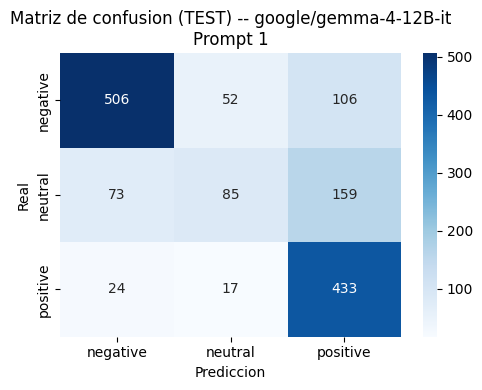

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_title(f"Matriz de confusion (TEST) -- {MODEL_ID}\nPrompt {PROMPT_ID}")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig(f"matriz_confusion_test_{MODEL_SHORT_NAME}.png", dpi=150)
plt.show()
